# Maximal radiated power with maximal field-weighted material density in the scattered-voltage basis $V_\mathrm{sca}$

Same setting as `VscatMaxRadMinField.ipynb` (global and GCD local power conservation constraints, optimization variable
$V_\mathrm{sca} = -Z_0 I$, $I = -W V_\mathrm{sca}$, $W = Z_0^{-1}$), with the field penalty replaced by the field-weighted material density of
`maxMatDens.ipynb`,
$$f = \tfrac12 I^H R_0 I + w\left(\operatorname{Re}\left[d^H a\right] - p\|d\|^2\right) = \tfrac12 I^H R_0 I + w\sum_i \left(\varsigma_i - p\right)|d_i|^2,$$
$$a_i = Z_s I_i, \qquad d_i = \left(V - Z_0 I\right)_i = \left(V + V_\mathrm{sca}\right)_i, \qquad w = 1\ \Omega^{-1}, \qquad p = 0.1 .$$
The bracket is the left-hand side of the fill-fraction constraint in `main.tex`: it rewards basis functions with density above $p$ in
proportion to the local intensity of the total field. For the full plate $a = d$ and the bracket equals $(1 - p)\|d\|^2$.
The notebook computes the global bound, refines it by `Ngcd` = 100 GCD iterations and infers the material density directly from $x^\star$.

In [14]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [15]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [16]:
geometry = "patch21ka1"   # "dipole" or "patch21ka1"

# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(f"Lmat_{geometry}.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(f"R0_{geometry}.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(f"X0_{geometry}.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(f"V_{geometry}.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

w = 0   # weight of the field-weighted density term (1/Ohm)
p = 0.1   # field-weighted fill fraction subtracted in the density term

def evalPradI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

def evalObjI(Ivec):
    # 1/2 I^H R0 I + w (Re[d^H a] - p ||d||^2), a = Zs I, d = V - Z0 I (current basis)
    d = Vinc - Z0 @ Ivec
    return(evalPradI(Ivec) + w*(np.real(np.vdot(d, Zs*Ivec)) - p*np.linalg.norm(d)**2))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W (radiated power {evalPradI(Ifull):.6e} W, ||d||^2 = {np.linalg.norm(Vinc - Z0 @ Ifull)**2:.6e} V^2)")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  233
Objective for full plate: 4.114174e-02 W (radiated power 4.114174e-02 W, ||d||^2 = 1.421460e-06 V^2)


## Objective in $V_\mathrm{sca}$

With $I = -W x$, $x = V_\mathrm{sca}$, $a = -Z_s W x$, $d = V + x$,
$$\operatorname{Re}\left[d^H a\right] = -x^H \operatorname{Sym}(Z_s W) x - \operatorname{Re}\left[x^H \overline{Z_s} W^H V\right],\qquad
\|d\|^2 = x^H x + 2\operatorname{Re}(x^H V) + \|V\|^2 ,$$
so the objective takes the dolphindes form $-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$ with
$$A_0 = -\tfrac12 W^H R_0 W + w\left[\operatorname{Sym}(Z_s W) + p\mathbf 1\right],\qquad
s_0 = -w\left(\tfrac12 \overline{Z_s}\, W^H V + pV\right),\qquad c_0 = -wp\|V\|^2 ,$$
where $\operatorname{Sym}(Z_s W) = W^H(R_s R_0 + X_s X_0)W$ is indefinite.

In [17]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W) + w*(Msym(Zs * W) + p*np.eye(Ndes))
obj = -w*(0.5*np.conj(Zs)*(WH @ Vinc) + p*Vinc)
obj0 = -w*p*np.linalg.norm(Vinc)**2

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

def fieldNorm2(Vsca):
    # ||d||^2, d = V + Vsca
    return(np.linalg.norm(Vinc + Vsca)**2)

def fieldWeightedDensity(Vsca):
    # Re[d^H a] / ||d||^2, a = Zs I, the field-weighted fill fraction p
    return(np.real(np.vdot(Vinc + Vsca, Zs*VtoI(Vsca)))/fieldNorm2(Vsca))

def reDa(Vsca):
    # Re[d^H a], a = Zs I, d = V + Vsca
    return(np.real(np.vdot(Vinc + Vsca, Zs*VtoI(Vsca))))

def report(Vsca):
    return(f"Prad {evalPradI(VtoI(Vsca)):.6e} W, Re[d^H a] {reDa(Vsca):.6e} V^2, ||d||^2 {fieldNorm2(Vsca):.6e} V^2, "
           f"field-weighted density {fieldWeightedDensity(Vsca):.6f}")

Vfull = -Z0 @ Ifull # scattered voltage for full plate
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random x: quadratic form {evalObj(xRand):.6e}, direct {evalObjI(VtoI(xRand)):.6e}")
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W), empty design region {evalObj(np.zeros(Ndes)):.6e} W")

cond(Z0) = 1.174e+03
random x: quadratic form 2.527624e-03, direct 2.527624e-03
Objective for full plate in Vsca: 4.114174e-02 W (I basis 4.114174e-02 W), empty design region 0.000000e+00 W


## Power conservation in the shared projector form

For a complex diagonal projector $P = \operatorname{diag}(p)$ the constraint $\operatorname{Re}\left[I^H P (V + V_\mathrm{sca} - Z_s I)\right] = 0$
holds for any structure. With $I = -W V_\mathrm{sca}$ it reads $\operatorname{Re}\left(-x^H B x + 2x^H s\right) = 0$,
$$B = W^H P (1 + Z_s W),\qquad s = -\tfrac12 W^H P V ,$$
without a constant. Using $\operatorname{Re}(x^H B x) = \operatorname{Re}(x^H B^H x)$, $B^H = (1 + Z_s^* W^H)\, P^*\, W$, this is the shared projector form
$\operatorname{Re}\left(-x^H A_1 P' A_2 x + 2 x^H A_2^H P'^H s_1\right) = 0$ with
$$A_1 = 1 + Z_s^* W^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 V,\qquad P' = P^H = \operatorname{diag}(p^*),$$
i.e. the current-basis constraint with $U^H = A_1$ and $I = -A_2 x$ written in $V_\mathrm{sca}$.

The global real ($p = \mathbf 1$) and reactive ($p = -j\mathbf 1$) power constraints are $P' = \mathbf 1$ and $P' = j\mathbf 1$.
For $P' = \mathbf 1$, $\operatorname{Sym}(A_1 A_2) = W^H \operatorname{Re}(Z_\mathrm{tot}) W$ (using $\operatorname{Sym}W = W^H R_0 W$),
the congruent image of the $I$-basis real power constraint.

In [18]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

qList = [1, -1j]   # real and imaginary part (real and reactive power), p = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[I^H diag(p) (V + Vsca - Zs I)] evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("power conservation residuals at full plate:",
      [f"{projRes(Vfull, Pp):.2e} (direct {directRes(Vfull, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

power conservation residuals at full plate: ['-1.39e-17 (direct -2.89e-17)', '4.44e-16 (direct -4.76e-16)']
random p, random x: shared form 6.816849e+00, direct 6.816849e+00


## Dual problem

With the real ($P' = \mathbf 1$) and reactive ($P' = j\mathbf 1$) power multipliers $\lambda$, $\mu$,
$$A(\lambda,\mu) = W^H\left[\left(\lambda - \tfrac12 + wR_s\right) R_0 + (\mu + wX_s) X_0 + \lambda R_s + \mu X_s\right] W + wp\mathbf 1 .$$
The choice $\mu = -wX_s$ cancels the indefinite $X_0$ part, and $\lambda = 1$ then gives
$A = W^H\left[\left(\tfrac12 + wR_s\right) R_0 + R_s - wX_s^2\right] W + wp\mathbf 1 \succ 0$ (as $wX_s < 1$), a dual feasible starting point.

In [19]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.array([1.0, -w*Zs.imag])   # lambda = 1, mu = -w Xs
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.847944e+01 W, time: 0.13s, Lagrange multipliers: [ 8.83797881e-01 -4.10993941e-05]


In [20]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, f(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), "
      f"full plate {Pfull:.6e} W, relative gap {(QCQP.current_dual - Pfull)/Pfull:.2e}")
print(f"x*: {report(Vstar)}")
print(f"full plate: {report(Vfull)}")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist])

minimum eigenvalue of A: 6.851e-09
dual bound 1.847944e+01 W, f(x*) 1.847944e+01 W (I basis 1.847944e+01 W), full plate 4.114174e-02 W, relative gap 4.48e+02
x*: Prad 1.847944e+01 W, Re[d^H a] 1.238175e-01 V^2, ||d||^2 1.053662e+07 V^2, field-weighted density 0.000000
full plate: Prad 4.114174e-02 W, Re[d^H a] 1.421460e-06 V^2, ||d||^2 1.421460e-06 V^2, field-weighted density 1.000000
constraint residuals at x*: ['-1.35e-07', '7.27e-04']


## Local projector constraints by GCD

Since the local constraints share $A_1$, $A_2$, $s_1$ with the global ones, they are generated directly by
`dolphindes.cvxopt.gcd.run_gcd`. Each GCD iteration adds two diagonal projectors $P' = \operatorname{diag}(p'^*)$:

1. **Strongest local violation:** $p'_i = (2s_1 - A_1^H x^\star)_i (A_2 x^\star)_i^*$, which equals
   $I_i^{\star *}\left(V + V^\star_{\mathrm{sca}} - Z_s I^\star\right)_i$ with $I^\star = -W x^\star$, the pointwise violation
   of the power conservation (zero for any physical structure).
2. **Minimal eigenvalue:** $p'_i = (A_1^H v)_i (A_2 v)_i^*$ for the eigenvector $v$ of $A(\lambda)$ with the smallest eigenvalue,
   normalized elementwise to unit modulus.

The projectors are kept orthonormal in the Hilbert-Schmidt metric of the constraints, and the number of projectors is capped at
`max_proj_cstrt_num`, which is set large enough that no constraints are merged within `max_gcd_iter_num` iterations.

In [21]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

Ngcd = 20   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

def localViolation(Vsca):
    # pointwise w_i = I_i^* (V + Vsca - Zs I)_i, zero for any physical structure
    I = VtoI(Vsca)
    return(np.conj(I)*(Vinc + Vsca - Zs*I))

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: {QCQP.current_dual:.6e} -> {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             18.479439958269765.
min eigenvalue: 6.851365e-09
At GCD iteration #2, best dual bound found is             18.331563359435165.
min eigenvalue: 5.900531e-09
At GCD iteration #3, best dual bound found is             18.2195828412249.
min eigenvalue: 3.891570e-09
At GCD iteration #4, best dual bound found is             18.116345292462576.
min eigenvalue: 1.260089e-09
At GCD iteration #5, best dual bound found is             18.058141958559176.
min eigenvalue: 3.000884e-10
At GCD iteration #6, best dual bound found is             18.014874448663974.
min eigenvalue: 4.902963e-11
At GCD iteration #7, best dual bound found is             17.996929898405355.
min eigenvalue: 3.607490e-10
At GCD iteration #8, best dual bound found is             17.976859355200386.
min eigenvalue: 3.852713e-13
At GCD iteration #9, best dual bound found is             17.96663304182734.
min eigenvalue: 2.472081e-13
At GCD iteration #10, best dual bound fo

minimum eigenvalue of A: 5.597e-15
dual bound 1.777878e+01 W, f(x*) 1.777831e+01 W, relative gap to full plate 4.31e+02
x*: Prad 1.777831e+01 W, Re[d^H a] -7.724185e+01 V^2, ||d||^2 7.878648e+06 V^2, field-weighted density -0.000010
max |constraint residual| at x*: 6.07e+03 (global), 9.72e+03 (all)
||local violation||: global 5.419e+03, GCD 2.898e+03


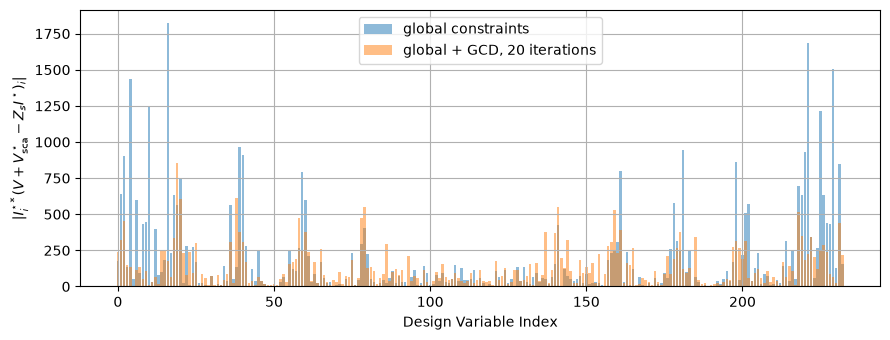

In [22]:
import matplotlib.pyplot as plt

Vstar = gQCQP.current_xstar
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
print(f"dual bound {gQCQP.current_dual:.6e} W, f(x*) {evalObj(Vstar):.6e} W, relative gap to full plate {(gQCQP.current_dual - Pfull)/Pfull:.2e}")
print(f"x*: {report(Vstar)}")
PlistG = gQCQP.Proj.get_Pdata_column_stack()
print(f"max |constraint residual| at x*: {max(abs(projRes(Vstar, Pp)) for Pp in Plist):.2e} (global), "
      f"{max(abs(projRes(Vstar, sp.diags(PlistG[:, j]))) for j in range(PlistG.shape[1])):.2e} (all)")
print(f"||local violation||: global {np.linalg.norm(localViolation(QCQP.current_xstar)):.3e}, "
      f"GCD {np.linalg.norm(localViolation(Vstar)):.3e}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(Ndes), np.abs(localViolation(QCQP.current_xstar)), alpha=0.5, label='global constraints')
ax.bar(np.arange(Ndes), np.abs(localViolation(Vstar)), alpha=0.5, label=f'global + GCD, {Ngcd} iterations')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel(r'$|I^{\star *}_i(V + V^\star_\mathrm{sca} - Z_s I^\star)_i|$')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Direct inference: complex material density

Material density per basis function (as in `densityConstraintsImag.ipynb`), from the total voltage $V + V_\mathrm{sca}$,
$$\rho_i = \frac{Z_s I_i}{V_i + V_{\mathrm{sca},i}}, \qquad I = -W V_\mathrm{sca},$$
equal to 1 on material and 0 on empty basis functions for a physical structure.

global constraints: Re rho in [-0.009, 0.010], Im rho in [-0.005, 0.015], ||Im rho||/||rho|| 7.274e-01
global + GCD, 20 iterations: Re rho in [-0.002, 0.013], Im rho in [-0.008, 0.004], ||Im rho||/||rho|| 6.021e-01


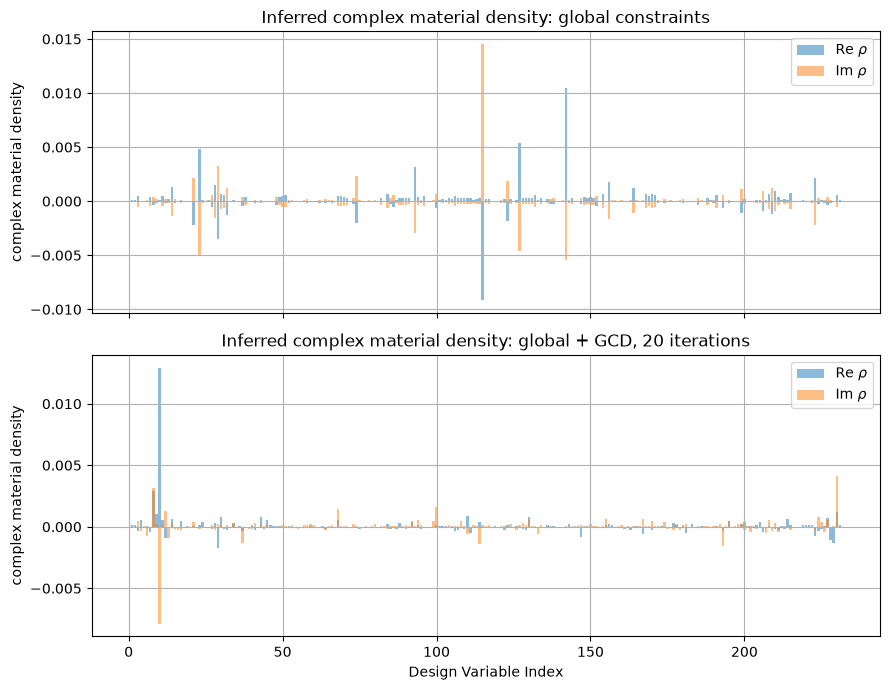

In [23]:
def complexDensity(Vsca):
    # inferred complex material density rho = Zs I / (V + Vsca) (Cholesky space)
    return Zs*VtoI(Vsca)/(Vinc + Vsca)

rhoGlob = complexDensity(QCQP.current_xstar)    # global constraints
rhoLoc = complexDensity(gQCQP.current_xstar)    # after Ngcd GCD iterations
cases = [("global constraints", rhoGlob), (f"global + GCD, {Ngcd} iterations", rhoLoc)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], "
          f"Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Inference optimization over the material density $\rho$

The ratio above gives a complex $\rho$ with no bounds. A physical structure needs a real $\rho_i \in [0, 1]$ such that the current is that
of the material excited by the total field, $I_i = \rho_i\, Z_s^{-1} E_{\mathrm{tot},i}$ with $E_\mathrm{tot} = V + V_\mathrm{sca}$.
The density is therefore inferred from the fit
$$\min_{\rho\in[0,1]^N} \left\| \operatorname{diag}(\rho)\, Z_s^{-1} E_\mathrm{tot} - I \right\|^2, \qquad I = -W V_\mathrm{sca},$$
which separates over the basis functions. With $b_i = E_{\mathrm{tot},i}/Z_s$ the minimizer is the projection onto the box
$$\rho_i = \operatorname{clip}\!\left(\frac{\operatorname{Re}(b_i^* I_i)}{|b_i|^2},\, 0,\, 1\right).$$
The design is then checked by solving the physical problem $(Z_s + \operatorname{diag}(\rho) Z_0)\, I = \operatorname{diag}(\rho)\, V$
and by a threshold sweep for a binary structure.

In [24]:
def fitDensity(Vsca):
    # argmin_{rho in [0,1]^N} || rho Etot/Zs - I ||, separable: projection of the pointwise least squares solution
    b = (Vinc + Vsca)/Zs
    I = VtoI(Vsca)
    rho = np.clip(np.real(np.conj(b)*I)/np.abs(b)**2, 0, 1)
    res = np.linalg.norm(rho*b - I)/np.linalg.norm(I)
    return rho, res

def realizedObj(rho):
    # objective 1/2 I^H R0 I + w (Re[d^H a] - p ||d||^2) of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I)

rhoFull, resFull = fitDensity(Vfull)
print(f"full plate check: rho in [{rhoFull.min():.6f}, {rhoFull.max():.6f}], relative fit residual {resFull:.2e}")

ths = np.linspace(0.05, 0.95, 19)
fits = {}
print(f"dual bound: global {QCQP.current_dual:.6e} W, GCD {gQCQP.current_dual:.6e} W, full plate {Pfull:.6e} W")
for name, Vs in [("global constraints", QCQP.current_xstar), (f"global + GCD, {Ngcd} iterations", gQCQP.current_xstar)]:
    rho, res = fitDensity(Vs)
    Pbin = np.array([realizedObj((rho > t).astype(float)) for t in ths])
    fits[name] = (rho, Pbin)
    print(f"{name}: relative fit residual {res:.3e}, mean density {rho.mean():.3f}, "
          f"realized objective {realizedObj(rho):.6e} W, best binary {Pbin.max():.6e} W (threshold {ths[np.argmax(Pbin)]:.2f})")

full plate check: rho in [1.000000, 1.000000], relative fit residual 9.89e-11
dual bound: global 1.847944e+01 W, GCD 1.777878e+01 W, full plate 4.114174e-02 W
global constraints: relative fit residual 8.504e-01, mean density 0.000, realized objective 8.738230e-03 W, best binary 0.000000e+00 W (threshold 0.05)
global + GCD, 20 iterations: relative fit residual 8.514e-01, mean density 0.000, realized objective 7.381287e-04 W, best binary 0.000000e+00 W (threshold 0.05)


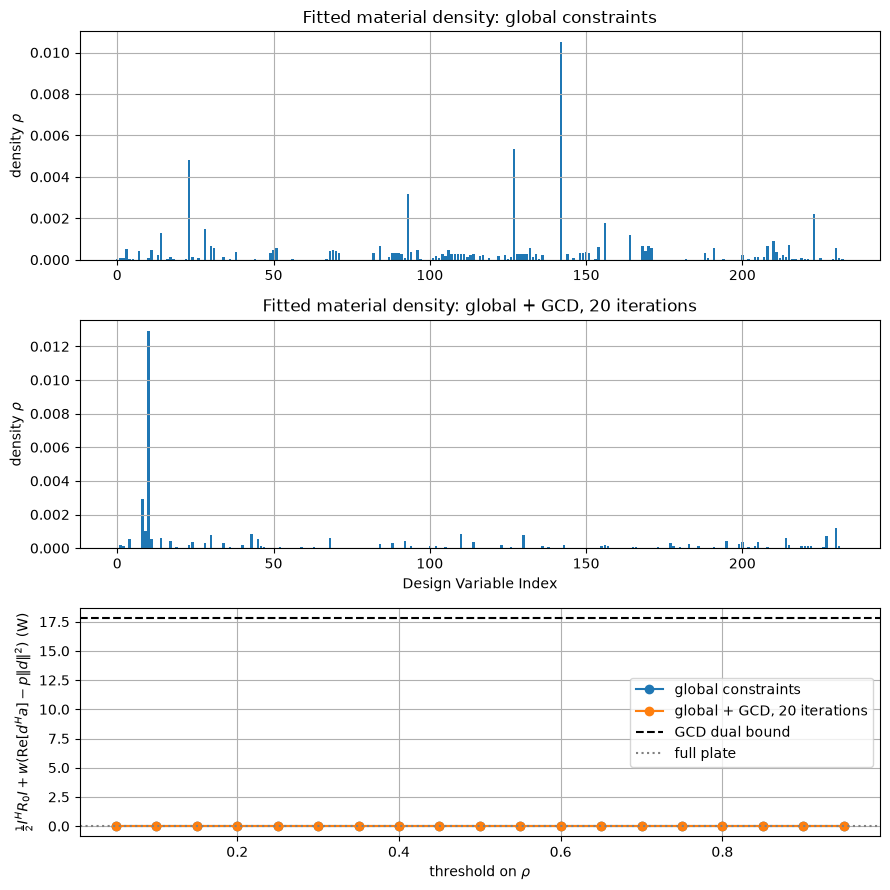

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, (name, (rho, _)) in zip(axes[:2], fits.items()):
    ax.bar(np.arange(Ndes), rho)
    ax.set_ylabel(r'density $\rho$'); ax.set_title(f'Fitted material density: {name}'); ax.grid(True)
axes[1].set_xlabel('Design Variable Index')
for name, (_, Pbin) in fits.items():
    axes[2].plot(ths, Pbin, 'o-', label=name)
axes[2].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_xlabel(r'threshold on $\rho$'); axes[2].set_ylabel(r'$\frac{1}{2}I^H R_0 I + w(\mathrm{Re}[d^H a] - p\|d\|^2)$ (W)'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()